In [327]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [328]:
import numpy as np
import pandas as pd

df = pd.read_csv(f"{path}/spam.csv",encoding='iso-8859-1' )

In [329]:
df.shape

(5572, 5)

In [266]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1191,ham,Come to my home for one last time i wont do an...,NaN,NaN,NaN
1816,ham,Are you going to write ccna exam this week??,NaN,NaN,NaN
4560,ham,Good afternoon my boytoy. How goes that walkin...,NaN,NaN,NaN
2354,ham,R we going with the &lt;#&gt; bus?,NaN,NaN,NaN
1230,ham,I want to send something that can sell fast. ...,NaN,NaN,NaN


1. Data Cleaning

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [330]:
# drop nan columns

df.drop(columns = ['Unnamed: 2'	,'Unnamed: 3'	,'Unnamed: 4'],inplace=True)

In [331]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [332]:
# rename columns

df.rename(columns= {"v1": 'Target' , 'v2' : 'Text'} , inplace=True)

In [333]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

In [334]:
df.sample(5)

,Target,Text
5557,0,No. I meant the calculation is the same. That ...
4584,1,U have a Secret Admirer who is looking 2 make ...
129,0,K..k:)how much does it cost?
923,0,She went to attend another two rounds today..b...
3799,1,We tried to contact you re your reply to our o...


In [335]:
# Missing Values

df.isnull().sum()

,0
Target,0
Text,0


In [274]:
# duplicate values

df.duplicated().sum()

np.int64(403)

In [336]:
# Remove Duplicates

df = df.drop_duplicates(keep='first')

2. EDA

In [337]:
# count targets

df['Target'].value_counts()

,count
Target,
0,4516
1,653


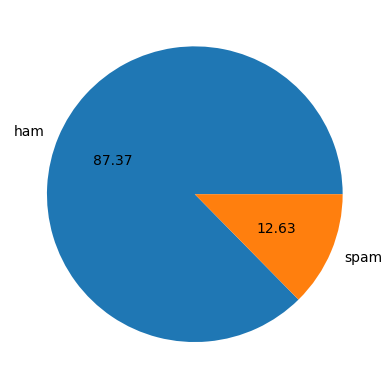

In [338]:
import matplotlib.pyplot as plt

plt.pie(x=df['Target'].value_counts() ,labels=['ham' , 'spam'], autopct='%0.2f' )
plt.show()

In [278]:
import nltk

In [279]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [339]:
df['Characters'] = df['Text'].apply(len)

In [281]:
df.head()

,Target,Text,Characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [340]:
df['Words'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [341]:
df['Sentences'] = df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [342]:
df[['Characters' ,'Words' , 'Sentences']].describe()

,Characters,Words,Sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [343]:
# Ham messages

df[df['Target']==0][['Characters' ,'Words' , 'Sentences']].describe()

,Characters,Words,Sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [344]:
# Spam messages

df[df['Target']==1][['Characters' ,'Words' , 'Sentences']].describe()

,Characters,Words,Sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='Characters', ylabel='Count'>

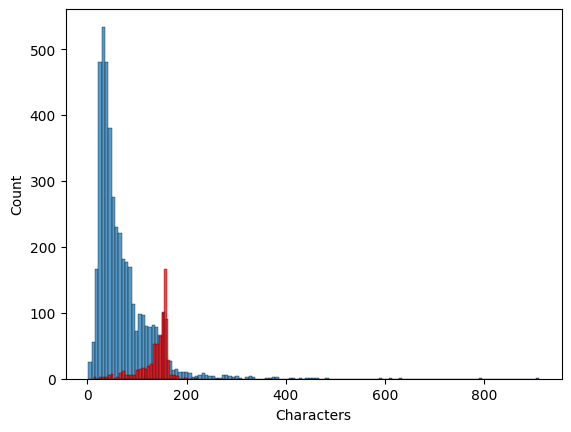

In [287]:
import seaborn as sns

sns.histplot(df[df['Target']==0]['Characters'])
sns.histplot(df[df['Target']==1]['Characters'], color='red')

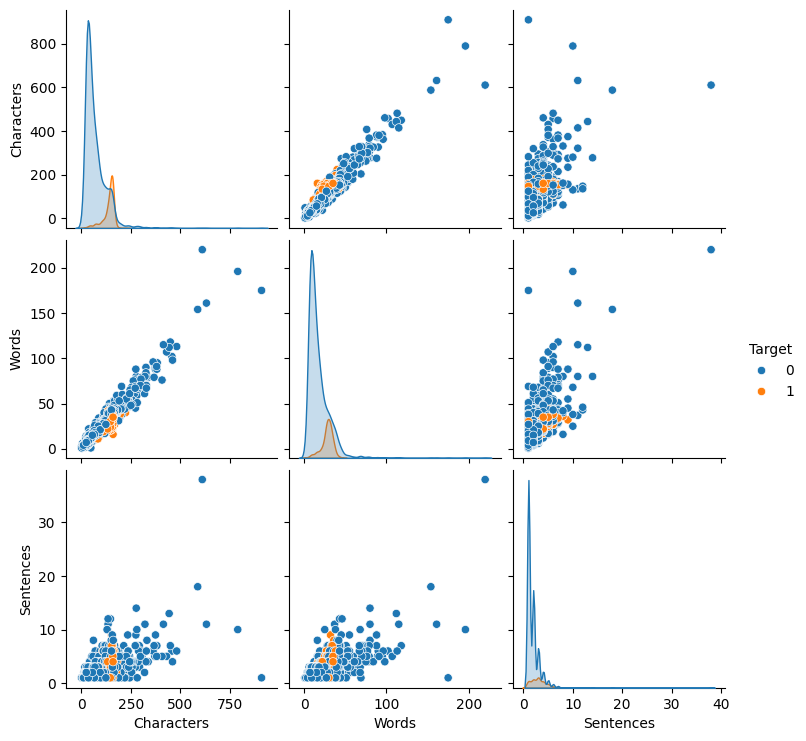

In [288]:
sns.pairplot(df , hue='Target')

<Axes: >

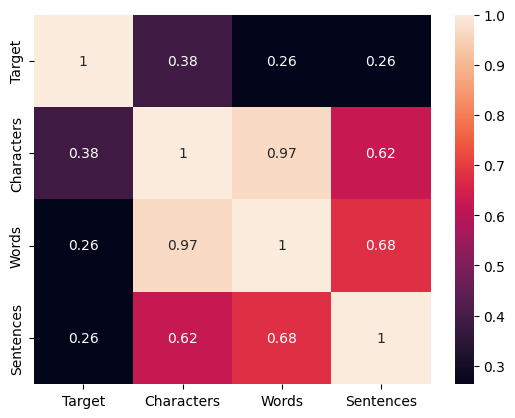

In [289]:
sns.heatmap(df[['Target' , 'Characters' ,'Words' , 'Sentences']].corr(),annot=True )

In [345]:
# Data Preprocessing
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

def tranform_text(text):

  text = text.lower()

  text = nltk.word_tokenize(text)

  y = []
  for word in text:
    if word.isalnum():
      y.append(word)

  text = y[:]
  y.clear()

  for word in text:
    if word not in stopwords.words('english') and word not in string.punctuation:
      y.append(word)

  ps = PorterStemmer()
  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [346]:
df['Transformed Text'] = df["Text"].apply(tranform_text)

In [347]:
df.head()

,Target,Text,Characters,Words,Sentences,Transformed Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [293]:
from wordcloud import WordCloud

wc = WordCloud(width=500 , height=500, min_font_size=10 , background_color='White')


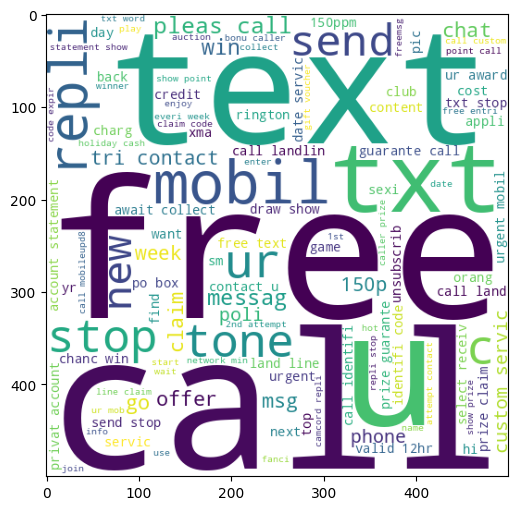

In [294]:
spam_wc = wc.generate(df[df['Target'] == 1]['Transformed Text'].str.cat(sep= " "))
plt.figure(figsize=(12, 6))
plt.imshow(spam_wc)

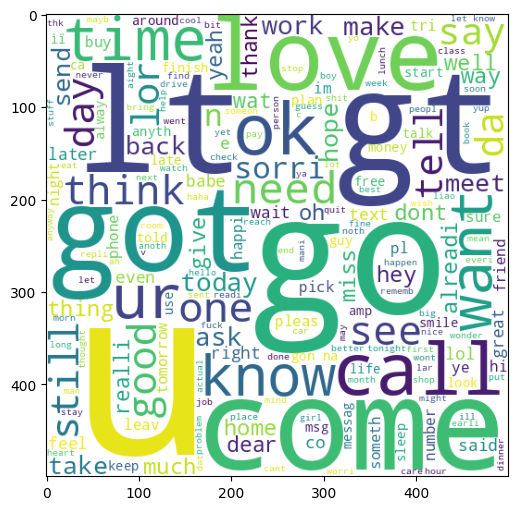

In [295]:
ham_wc = wc.generate(df[df['Target'] == 0]['Transformed Text'].str.cat(sep= " "))
plt.figure(figsize=(12, 6))
plt.imshow(ham_wc)

In [296]:
from collections import Counter


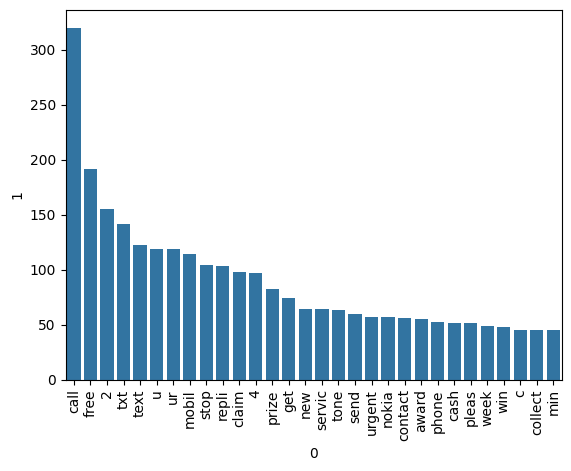

In [348]:
spam_corpus = []
for message in df[df['Target']==1]['Transformed Text'].tolist():
  for word in message.split():
    spam_corpus.append(word)

sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] , y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

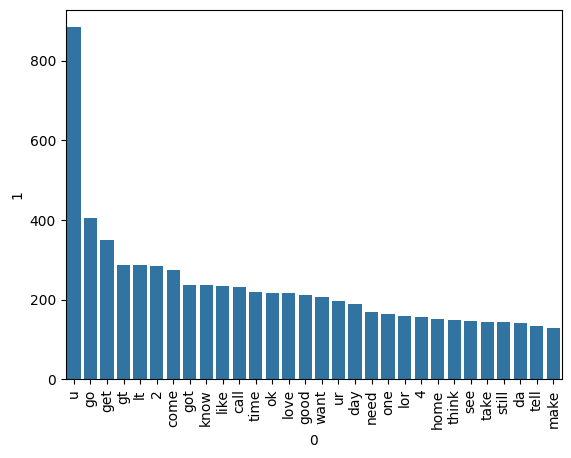

In [298]:
ham_corpus = []
for message in df[df['Target']==0]['Transformed Text'].tolist():
  for word in message.split():
    ham_corpus.append(word)

sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0] , y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

Text to Vectors




In [349]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [350]:
# for countvector
# X = cv.fit_transform(df['Transformed Text']).toarray()

# for tfidf
X = tfidf.fit_transform(df['Transformed Text']).toarray()


In [351]:
# X = np.hstack((X , df['Characters'].values.reshape(-1,1)))

In [352]:
y = df['Target'].values

Models

In [353]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB , BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , precision_score , recall_score , f1_score

In [354]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled , y , test_size = 0.2 , random_state=42 , stratify=y)

In [355]:
gnv_model = GaussianNB()
gnv_model.fit(X_train , y_train)

y_pred_gnv = gnv_model.predict(X_test)

print("Confusion Matrix :\n " , confusion_matrix(y_test , y_pred_gnv))
print("accuracy_score : " , accuracy_score(y_test , y_pred_gnv))
print("precision_score : " , precision_score(y_test , y_pred_gnv))
print("recall_score : " , recall_score(y_test , y_pred_gnv))

Confusion Matrix :
  [[801 102]
 [ 23 108]]
accuracy_score :  0.879110251450677
precision_score :  0.5142857142857142
recall_score :  0.8244274809160306


In [316]:
mnv_model = MultinomialNB()
mnv_model.fit(X_train , y_train)

y_pred_mnv = mnv_model.predict(X_test)

print("Confusion Matrix :\n " , confusion_matrix(y_test , y_pred_mnv))
print("accuracy_score : " , accuracy_score(y_test , y_pred_mnv))
print("precision_score : " , precision_score(y_test , y_pred_mnv))
print("recall_score : " , recall_score(y_test , y_pred_mnv))

Confusion Matrix :
  [[901   2]
 [ 56  75]]
accuracy_score :  0.9439071566731141
precision_score :  0.974025974025974
recall_score :  0.5725190839694656


In [356]:
bnv_model = BernoulliNB()
bnv_model.fit(X_train , y_train)

y_pred_bnv = bnv_model.predict(X_test)

print("Confusion Matrix :\n " , confusion_matrix(y_test , y_pred_bnv))
print("accuracy_score : " , accuracy_score(y_test , y_pred_bnv))
print("precision_score : " , precision_score(y_test , y_pred_bnv))
print("recall_score : " , recall_score(y_test , y_pred_bnv))

Confusion Matrix :
  [[902   1]
 [ 16 115]]
accuracy_score :  0.9835589941972921
precision_score :  0.9913793103448276
recall_score :  0.8778625954198473


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier


In [236]:
lc = LogisticRegression()
knc = KNeighborsClassifier()
nv = BernoulliNB()
svc = SVC(kernel='sigmoid' , gamma=0.1)
dtc = DecisionTreeClassifier(max_depth=5)
rfc = RandomForestClassifier(n_estimators=50 , random_state=42)
etc = ExtraTreesClassifier(n_estimators=50 , random_state=42)
abc = AdaBoostClassifier(n_estimators=50 , random_state=42)
xgbc = XGBClassifier(n_estimators=50 , random_state=42)
bc = BaggingClassifier(n_estimators=50 , random_state=42)


In [237]:
models = {
    'LC': lc,
    'KNC': knc,
    'NV': nv,
    'SVC': svc,
    'DTC': dtc,
    'RFC': rfc,
    'ETC': etc,
    'ABC': abc,
    'XGBC': xgbc,
    'BC': bc
}

In [238]:
def train_classifier(model , X_train , X_test, y_train  , y_test):
  model.fit(X_train ,y_train )
  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test , y_pred)
  precision = precision_score(y_test, y_pred, zero_division=0)
  recall = recall_score(y_test, y_pred, zero_division=0)
  f1 = f1_score(y_test, y_pred, zero_division=0)

  return accuracy , precision , recall , f1


In [239]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for name , model in models.items():
  acc , prec , rec , f1 = train_classifier(model , X_train , X_test , y_train , y_test)
  accuracy_scores.append(acc)
  precision_scores.append(prec)
  recall_scores.append(rec)
  f1_scores.append(f1)



In [244]:
performance_df = pd.DataFrame({
    'Model': models.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1' : f1_scores
}).sort_values('F1' , ascending=False)

In [245]:
performance_df


,Model,Accuracy,Precision,Recall,F1
2,NV,0.983559,0.991379,0.877863,0.931174
6,ETC,0.977756,0.965517,0.854962,0.906883
5,RFC,0.974855,0.981651,0.816794,0.891667
8,XGBC,0.969052,0.945946,0.801527,0.867769
9,BC,0.950677,0.807692,0.801527,0.804598
0,LC,0.955513,1.000000,0.648855,0.787037
4,DTC,0.938104,0.819048,0.656489,0.728814
7,ABC,0.923598,0.770833,0.564885,0.651982
3,SVC,0.929400,1.000000,0.442748,0.613757
1,KNC,0.906190,1.000000,0.259542,0.412121


In [326]:
# Voting Classsifier
from sklearn.ensemble import VotingClassifier

svc = SVC(kernel = 'sigmoid' , gamma=0.1 , probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50 , random_state=42 )

voting = VotingClassifier(estimators = [('svc' , svc), ('mnb', mnb) , ('etc', etc)], voting='soft')

voting.fit(X_train , y_train)

y_pred_voting = voting.predict(X_test)

print("Confusion Matrix :\n " , confusion_matrix(y_test , y_pred_voting))
print("accuracy_score : " , accuracy_score(y_test , y_pred_voting))
print("precision_score : " , precision_score(y_test , y_pred_voting))
print("recall_score : " , recall_score(y_test , y_pred_voting))

Confusion Matrix :
  [[903   0]
 [ 61  70]]
accuracy_score :  0.9410058027079303
precision_score :  1.0
recall_score :  0.5343511450381679


In [357]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl' , 'wb'))
pickle.dump(bnv_model , open('model.pkl', 'wb'))